# Itinerary planner — LangGraph starter

A ReAct-style agent that plans a trip from either:

1. **a YouTube travel video** — the transcript is mined for the places visited and the route taken, or
2. **web research** — when no video is given, OpenAI web search researches the destination.

Both need your **current location**; web research also needs a **destination**. If something is missing, the graph asks for it and ends the turn — reply on the same `thread_id` to continue.

Run the cells top to bottom with the **Python (itinerary-planner)** kernel. Nothing calls the API until the *Run* section at the bottom.

## Setup

In [21]:
%load_ext dotenv
%dotenv

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [22]:
import os

if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("OPENAI_API_KEY is not set — add it to the project's .env file and re-run the %dotenv cell.")

In [23]:
import re
from urllib.parse import parse_qs, urlparse

from IPython.display import Image, Markdown, display
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field
from youtube_transcript_api import YouTubeTranscriptApi

# Shared with the backend: tool-error handling and repair of threads left with unanswered tool calls.
from itinerary_planner.graph import drop_unanswered_tool_calls
from itinerary_planner.tools import describe_tool_error

MODEL_NAME = "gpt-5.4-mini"

llm = ChatOpenAI(model=MODEL_NAME)

## State and schemas

In [24]:
class TripPlannerState(MessagesState):
    """Conversation messages plus the trip details extracted from them."""

    current_location: str | None
    destination: str | None
    youtube_url: str | None


class TripDetails(BaseModel):
    """Trip details the user has stated so far in the conversation."""

    current_location: str | None = Field(
        default=None, description="Where the user is now / travelling from. Null if not stated."
    )
    destination: str | None = Field(
        default=None, description="Where the user wants to go. Null if not stated."
    )


class RouteStop(BaseModel):
    name: str = Field(description="Place name, specific enough to look up on a map.")
    highlights: str = Field(description="What was done or seen there, in one or two sentences.")


class VideoRoute(BaseModel):
    """The trip shown in a travel video."""

    region: str = Field(description="Country / region / city the video covers.")
    stops: list[RouteStop] = Field(description="Places visited, in the order shown in the video.")
    travel_tips: list[str] = Field(
        default_factory=list, description="Practical tips mentioned: transport, costs, timing, bookings."
    )

## YouTube helpers

In [25]:
YOUTUBE_URL_PATTERN = re.compile(
    r"https?://(?:www\.|m\.)?(?:youtube\.com/(?:watch\?\S+|shorts/\S+|embed/\S+)|youtu\.be/\S+)"
)


def find_youtube_url(text: str) -> str | None:
    """Return the first YouTube URL in `text`, if any."""
    match = YOUTUBE_URL_PATTERN.search(text)
    return match.group(0) if match else None


def parse_video_id(youtube_url: str) -> str:
    """Extract the video id from watch, youtu.be, shorts and embed URLs."""
    parsed = urlparse(youtube_url)
    host = parsed.netloc.removeprefix("www.").removeprefix("m.")
    path_parts = [part for part in parsed.path.split("/") if part]

    if host == "youtu.be" and path_parts:
        return path_parts[0]
    if host == "youtube.com":
        if parsed.path == "/watch" and (video_ids := parse_qs(parsed.query).get("v")):
            return video_ids[0]
        if len(path_parts) >= 2 and path_parts[0] in {"shorts", "embed"}:
            return path_parts[1]
    raise ValueError(f"Not a recognised YouTube video URL: {youtube_url!r}")

In [26]:
# Offline sanity checks — no API calls.
assert parse_video_id("https://www.youtube.com/watch?v=abc123XYZ_-&t=42s") == "abc123XYZ_-"
assert parse_video_id("https://youtu.be/abc123XYZ_-?si=share") == "abc123XYZ_-"
assert parse_video_id("https://youtube.com/shorts/abc123XYZ_-") == "abc123XYZ_-"
assert find_youtube_url("Plan this trip https://youtu.be/abc123 please") == "https://youtu.be/abc123"
assert find_youtube_url("Trip to Kyoto from Chicago") is None
print("helpers OK")

helpers OK


## Tools

In [27]:
route_extractor = llm.with_structured_output(VideoRoute)


@tool
def extract_route_from_youtube(youtube_url: str, current_location: str) -> str:
    """Extract the region, the ordered stops and the travel tips from a YouTube travel video.

    Use this whenever the user shared a YouTube URL. Returns JSON describing the route
    taken in the video, which you then adapt into an itinerary starting from current_location.
    """
    transcript = YouTubeTranscriptApi().fetch(parse_video_id(youtube_url), languages=["en"])
    transcript_text = " ".join(snippet.text for snippet in transcript)

    route = route_extractor.invoke(
        [
            SystemMessage(
                "You extract travel routes from video transcripts. List only places actually "
                "visited in the video, in the order they were visited."
            ),
            HumanMessage(
                f"The viewer will travel from {current_location}.\n\nTranscript:\n{transcript_text}"
            ),
        ]
    )
    return route.model_dump_json()

In [28]:
web_researcher = ChatOpenAI(model=MODEL_NAME, use_responses_api=True).bind_tools(
    [{"type": "web_search"}]
)


@tool
def research_destination(current_location: str, destination: str) -> str:
    """Research a destination on the web to plan a trip there from current_location.

    Use this only when the user did NOT share a YouTube URL. Returns a research summary:
    how to get there, the must-see places, a sensible order to visit them, and practical notes.
    """
    response = web_researcher.invoke(
        f"I am travelling from {current_location} to {destination}. Search the web and summarise:\n"
        "1. How to get there from my location (transport options, rough travel time).\n"
        "2. The top places to visit and what each is known for.\n"
        "3. A sensible order to visit them, grouped by area.\n"
        "4. Current practical notes: best season, local transport, bookings, costs."
    )
    return response.text


tools = [extract_route_from_youtube, research_destination]

## Nodes

In [29]:
details_extractor = llm.with_structured_output(TripDetails)


def extract_trip_details(state: TripPlannerState) -> dict:
    """Pull the current location, destination and YouTube URL out of the conversation."""
    details = details_extractor.invoke(
        [
            SystemMessage(
                "Extract the trip details the user has stated anywhere in this conversation. "
                "Use null for anything not stated; never guess."
            ),
            *drop_unanswered_tool_calls(state["messages"]),
        ]
    )
    human_texts = (m.text for m in state["messages"] if isinstance(m, HumanMessage))
    youtube_url = next((url for text in human_texts if (url := find_youtube_url(text))), None)
    return {
        "current_location": details.current_location,
        "destination": details.destination,
        "youtube_url": youtube_url,
    }


def find_missing_details(state: TripPlannerState) -> list[str]:
    """Details required before planning: location always; destination only without a video."""
    missing = []
    if not state.get("current_location"):
        missing.append("your current location (where you'll be travelling from)")
    if not state.get("youtube_url") and not state.get("destination"):
        missing.append("your destination, or a YouTube travel video URL to base the trip on")
    return missing


def route_after_extraction(state: TripPlannerState) -> str:
    return "request_missing_details" if find_missing_details(state) else "planner"


def request_missing_details(state: TripPlannerState) -> dict:
    missing = find_missing_details(state)
    bullet_list = "\n".join(f"- {item}" for item in missing)
    return {"messages": [AIMessage(f"To plan your itinerary I still need:\n{bullet_list}")]}


planner_llm = llm.bind_tools(tools)

PLANNER_PROMPT = """You are a travel itinerary planner.

Known trip details:
- Current location: {current_location}
- Destination: {destination}
- YouTube video: {youtube_url}

Gather information first:
- If a YouTube video is given, call extract_route_from_youtube and base the trip on the route in the video.
- Otherwise, call research_destination.

If a tool result starts with "TOOL ERROR":
- Tell the user plainly what went wrong (e.g. the video has no transcript), without technical jargon.
- If the destination is known, fall back to research_destination and still plan the trip.
- Otherwise, ask the user for another video or for their destination. Never make up a route.

Then write a day-by-day itinerary: getting there from the current location, each day's stops in
a sensible order, and practical tips. Do not invent places the tools did not mention."""


def planner(state: TripPlannerState) -> dict:
    system_prompt = PLANNER_PROMPT.format(
        current_location=state["current_location"],
        destination=state.get("destination") or "not given",
        youtube_url=state.get("youtube_url") or "not given",
    )
    response = planner_llm.invoke([SystemMessage(system_prompt), *drop_unanswered_tool_calls(state["messages"])])
    return {"messages": [response]}

## Build and compile the graph

In [30]:
builder = StateGraph(TripPlannerState)

builder.add_node("extract_trip_details", extract_trip_details)
builder.add_node("request_missing_details", request_missing_details)
builder.add_node("planner", planner)
builder.add_node("tools", ToolNode(tools, handle_tool_errors=describe_tool_error))

builder.add_edge(START, "extract_trip_details")
builder.add_conditional_edges(
    "extract_trip_details", route_after_extraction, ["request_missing_details", "planner"]
)
builder.add_edge("request_missing_details", END)
builder.add_conditional_edges("planner", tools_condition)  # tool calls -> "tools", else END
builder.add_edge("tools", "planner")

graph = builder.compile(checkpointer=InMemorySaver())

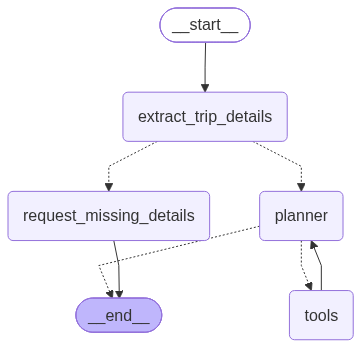

In [31]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:  # PNG rendering needs network access to mermaid.ink
    print(graph.get_graph().draw_mermaid())

## Run

Each cell below calls the API. Results are stored in variables so you can inspect them in later cells without re-running the model.

Every conversation gets a fresh `thread_id` from `new_thread_config()`, so re-running a cell starts a clean conversation instead of piling onto (or replaying a broken) history. To continue a conversation, reuse its config — as the follow-up cell does.

If the kernel was running before the notebook changed: **Kernel → Restart Kernel and Run All Cells**.

In [32]:
import uuid


def new_thread_config() -> dict:
    """Config for a brand-new conversation (the checkpointer keys history by thread_id)."""
    return {"configurable": {"thread_id": str(uuid.uuid4())}}


def show_reply(result: dict) -> None:
    display(Markdown(result["messages"][-1].text))


missing_info_config = new_thread_config()
missing_info_result = graph.invoke(
    {"messages": [HumanMessage("Plan me a 4-day trip to Kyoto.")]}, missing_info_config
)
show_reply(missing_info_result)

To plan your itinerary I still need:
- your current location (where you'll be travelling from)

In [33]:
# Follow-up on the same thread: the location is now known, so the planner runs (web research).
follow_up_result = graph.invoke(
    {"messages": [HumanMessage("I'm in Tokyo.")]}, missing_info_config
)
show_reply(follow_up_result)

Here’s a practical **4-day Kyoto itinerary** starting from **Tokyo**.

## Getting there from Tokyo
The easiest way is the **Tokaido Shinkansen** from **Tokyo Station to Kyoto Station**.
- **Nozomi**: about **2 hr 10 min**
- **Hikari**: about **2 hr 50 min**

If you can, take an **early train** so you have most of day 1 in Kyoto.

---

## Day 1: Arrive in Kyoto + East Kyoto
**Best for: classic Kyoto atmosphere, temples, old streets**

### Morning
- Travel from **Tokyo to Kyoto** by Shinkansen
- Check in or drop bags at your hotel near Kyoto Station or central Kyoto

### Afternoon
- **Kiyomizu-dera**
- Walk through the nearby **Higashiyama** area
- Explore **Gion**

### Evening
- Stay in **Gion** or nearby for dinner and a relaxed walk
- Good first-day pace: mostly walking, no long transfers

### Tip
Go to **Kiyomizu-dera** and **Higashiyama** as early as possible if you want fewer crowds.

---

## Day 2: Fushimi Inari + central Kyoto
**Best for: iconic Kyoto sights with easy transport**

### Morning
- **Fushimi Inari Taisha**
- Go early for the best experience and lighter crowds

### Afternoon
- Return to central Kyoto
- Visit **Nijo Castle**

### Evening
- Free time around central Kyoto for shopping, food, or a quieter temple/café stop

### Tip
**Fushimi Inari** is easy from Kyoto Station, so it’s a good first stop before moving back to the city.

---

## Day 3: Arashiyama
**Best for: bamboo grove, river scenery, western Kyoto**

### Morning
- Head to **Arashiyama**
- Visit the **bamboo grove**

### Afternoon
- Continue exploring the **Arashiyama** area at a relaxed pace
- Enjoy the riverside and surrounding sights

### Evening
- Return to central Kyoto
- Keep dinner simple, since Arashiyama is the main sightseeing focus today

### Tip
Arashiyama is best treated as its own half-day or full-day area so you don’t rush.

---

## Day 4: North Kyoto + depart or relax
**Best for: Kyoto’s most famous landmark**

### Morning
- **Kinkaku-ji** in the morning

### Afternoon
- If you have time, revisit a favorite area or do some last-minute shopping/souvenir browsing
- Head back to your hotel to collect bags

### Evening
- Return to Tokyo, or stay one more night if your schedule allows

### Tip
Pairing **Kinkaku-ji** with another central/north Kyoto stop works well, but keep travel time in mind.

---

## Practical tips
- **Stay near Kyoto Station** for easy arrivals, departures, and day trips
- Use **trains + subway + buses** instead of relying only on buses
- For busy seasons, start early, especially for:
  - **Kiyomizu-dera**
  - **Gion / Higashiyama**
  - **Arashiyama**
- If you’re moving around a lot in one day, a **day pass** may be useful

If you want, I can also turn this into a **more detailed version with lunch/dinner suggestions and estimated transit times**.

In [34]:
# Swap in any travel vlog URL. A video without a transcript is fine too: the planner explains the problem.
youtube_config = new_thread_config()
youtube_result = graph.invoke(
    {"messages": [HumanMessage("I'm in London. Plan my trip like this video: https://www.youtube.com/watch?v=CDeir5EAwMc")]},
    youtube_config,
)
show_reply(youtube_result)

Here’s a trip plan based on the video route, starting from London and following the San Francisco itinerary shown.

## Overview
**Destination:** San Francisco, California, USA  
**Route in the video:** Chinatown → Golden Gate Park → Ocean Beach → Lands End → Sutro Baths → Cliff House

## Getting there from London
- **Fly from London to San Francisco International Airport (SFO)** or Oakland if you find a better fare.
- From SFO, take BART + Muni, a rideshare, or a taxi into the city.
- If you want to follow the video route comfortably, stay somewhere central in San Francisco so you can move between neighborhoods easily.

## Day 1: Chinatown
### Stops
1. **Dragon Gate, Chinatown**
2. Walk along **Grant Avenue**
3. Continue to **Stockton Street**

### What to do
- Enter Chinatown through the Dragon Gate.
- Browse shops for ingredients and local goods.
- Stop for **jasmine tea**.
- Have Chinese food for lunch or an early dinner.

### Practical tip
- Chinatown is easiest to explore on foot. Go earlier in the day if you want a quieter visit.

## Day 2: Golden Gate Park
### Stops
1. **Golden Gate Park**
2. **Conservatory of Flowers**
3. **California Academy of Sciences**
4. **de Young Museum**
5. **Bison pasture near Spreckels Lake**

### What to do
- Spend most of the day in the park.
- Visit the gardens and choose one or two indoor attractions depending on your pace.
- Make time for the bison area near Spreckels Lake.

### Practical tip
- Golden Gate Park is huge, so don’t try to do everything in one rush. Pick a few highlights and plan for plenty of walking.

## Day 3: West Coast shoreline
### Stops
1. **Ocean Beach**
2. **Lands End**
3. **Sutro Baths**
4. **Cliff House**

### What to do
- Start at **Ocean Beach** and enjoy the long stretch of shoreline.
- Continue to **Lands End** for coastal views.
- Walk to the **Sutro Baths** ruins.
- Finish at **Cliff House** for panoramic views and a relaxed end to the day.

### Practical tip
- **Lands End and Sutro Baths** work best together as one coastal walk.
- Bring layers: the western shoreline can be windy and chilly even when the rest of the city feels mild.

## Suggested pacing
- **Day 1:** Chinatown
- **Day 2:** Golden Gate Park
- **Day 3:** Ocean Beach → Lands End → Sutro Baths → Cliff House

## General tips
- San Francisco is compact enough that these areas are manageable, but some parts are spread out, so use transit or rideshares between neighborhoods.
- Comfortable walking shoes are important.
- If you want, I can also turn this into a **budget version**, **luxury version**, or a **3-day hour-by-hour itinerary**.